# Exercise 5 — Variance reduction methods

Estimate $\theta=\int_0^1 e^x dx = e-1 \approx 1.718$ with crude MC and variance-reduction methods.
(Part 6 skipped.)

In [1]:
%matplotlib inline
import heapq
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as tdist, norm

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)
THETA = np.e - 1
VAR_CRUDE = (np.e**2 - 1) / 2 - (np.e - 1)**2

def ci_t(sample, conf=0.95):
    s = np.asarray(sample, float); n = len(s); m = s.mean()
    half = tdist.ppf(0.5 + conf/2, n-1) * s.std(ddof=1) / np.sqrt(n)
    return dict(mean=m, lo=m-half, hi=m+half, half=half, var_est=s.var(ddof=1)/n)

## Part 1 — Crude Monte Carlo (n=100)

In [2]:
U = rng.random(100); X = np.exp(U); r = ci_t(X)
print(f"crude: {r['mean']:.4f}  95% CI [{r['lo']:.4f}, {r['hi']:.4f}]  Var[est]={r['var_est']:.2e}")

crude: 1.7372  95% CI [1.6474, 1.8269]  Var[est]=2.05e-03


## Part 2 — Antithetic variables  $Y_i=\tfrac12(e^{U_i}+e^{1-U_i})$ (50 pairs)

In [3]:
U = rng.random(50); Y = (np.exp(U) + np.exp(1-U))/2; r = ci_t(Y)
print(f"antithetic: {r['mean']:.4f}  95% CI [{r['lo']:.4f}, {r['hi']:.4f}]  Var[est]={r['var_est']:.2e}")

antithetic: 1.7093  95% CI [1.6937, 1.7249]  Var[est]=6.05e-05


## Part 3 — Control variate  $Y_i=X_i+c(U_i-\tfrac12)$,  $c=-\mathrm{Cov}/\mathrm{Var}$

In [4]:
U = rng.random(100); X = np.exp(U)
c = -np.cov(X, U)[0,1] / U.var(ddof=1)
Y = X + c*(U - 0.5); r = ci_t(Y)
print(f"c = {c:.3f}")
print(f"control: {r['mean']:.4f}  95% CI [{r['lo']:.4f}, {r['hi']:.4f}]  Var[est]={r['var_est']:.2e}")

c = -1.697
control: 1.7163  95% CI [1.7040, 1.7287]  Var[est]=3.87e-05


## Part 4 — Stratified sampling (K=10 strata, n=10)

In [5]:
K = 10; j = np.arange(K)
Y = np.array([np.mean(np.exp((j + rng.random(K))/K)) for _ in range(10)]); r = ci_t(Y)
print(f"stratified: {r['mean']:.4f}  95% CI [{r['lo']:.4f}, {r['hi']:.4f}]  Var[est]={r['var_est']:.2e}")

stratified: 1.7252  95% CI [1.7096, 1.7408]  Var[est]=4.76e-05


### Estimator variance comparison (2000 macro-replications)

In [6]:
def crude(rng): return np.exp(rng.random(100)).mean()
def antithetic(rng):
    U = rng.random(50); return ((np.exp(U)+np.exp(1-U))/2).mean()
def control(rng):
    U = rng.random(100); X = np.exp(U)
    c = -np.cov(X, U)[0,1]/U.var(ddof=1); return (X + c*(U-0.5)).mean()
def stratified(rng):
    j = np.arange(10); return np.mean([np.mean(np.exp((j+rng.random(10))/10)) for _ in range(10)])

for name, fn in [("crude", crude), ("antithetic", antithetic), ("control", control), ("stratified", stratified)]:
    e = np.array([fn(rng) for _ in range(2000)])
    print(f"{name:12s} Var[est]={e.var(ddof=1):.2e}  reduction vs crude = {VAR_CRUDE/100/e.var(ddof=1):.1f}x")

crude        Var[est]=2.49e-03  reduction vs crude = 1.0x
antithetic   Var[est]=7.64e-05  reduction vs crude = 31.7x
control      Var[est]=3.99e-05  reduction vs crude = 60.7x


stratified   Var[est]=2.79e-05  reduction vs crude = 86.9x


## Part 5 — Control variate for the blocking system (Exercise 4, Poisson arrivals)

In [7]:
def sim_block(n_cust, m, rng, mean_ia=1.0, mean_s=8.0):
    busy = []; blocked = 0; t = 0.0; s_sum = 0.0
    for _ in range(n_cust):
        t += rng.exponential(mean_ia)
        while busy and busy[0] <= t: heapq.heappop(busy)
        s = rng.exponential(mean_s); s_sum += s
        if len(busy) < m: heapq.heappush(busy, t + s)
        else: blocked += 1
    return blocked / n_cust, s_sum / n_cust

reps = 100
X = np.empty(reps); Z = np.empty(reps)
for r in range(reps): X[r], Z[r] = sim_block(10_000, 10, rng)
c = -np.cov(X, Z)[0,1]/Z.var(ddof=1)
Y = X + c*(Z - 8.0)
rx, ry = ci_t(X), ci_t(Y)
print(f"corr={np.corrcoef(X,Z)[0,1]:.3f}  c={c:.5f}")
print(f"crude  : {rx['mean']:.4f} CI [{rx['lo']:.4f},{rx['hi']:.4f}]  Var={X.var(ddof=1):.2e}")
print(f"control: {ry['mean']:.4f} CI [{ry['lo']:.4f},{ry['hi']:.4f}]  Var={Y.var(ddof=1):.2e}")
print(f"reduction = {1 - Y.var(ddof=1)/X.var(ddof=1):.1%}")

corr=0.616  c=-0.05123
crude  : 0.1206 CI [0.1193,0.1219]  Var=4.26e-05
control: 0.1208 CI [0.1198,0.1218]  Var=2.64e-05
reduction = 37.9%


## Part 7 — Importance sampling for $P(Z>a)$,  proposal $N(a,\sigma^2)$

In [8]:
def crude_tail(a, n, rng): return (rng.standard_normal(n) > a).astype(float)
def is_tail(a, n, sigma, rng):
    Y = rng.normal(a, sigma, n); return (Y > a)*norm.pdf(Y)/norm.pdf(Y, a, sigma)

for a in (2, 4):
    print(f"a={a} (true {norm.sf(a):.3e})")
    for n in (1_000, 100_000):
        rc, ri = ci_t(crude_tail(a, n, rng)), ci_t(is_tail(a, n, 1.0, rng))
        print(f"  n={n:>7}: crude {rc['mean']:.3e} (Var {rc['var_est']:.1e}) | "
              f"IS {ri['mean']:.3e} (Var {ri['var_est']:.1e})  ratio {rc['var_est']/ri['var_est']:.0f}x")

a=2 (true 2.275e-02)
  n=   1000: crude 2.700e-02 (Var 2.6e-05) | IS 2.372e-02 (Var 1.3e-06)  ratio 20x
  n= 100000: crude 2.211e-02 (Var 2.2e-07) | IS 2.269e-02 (Var 1.2e-08)  ratio 18x
a=4 (true 3.167e-05)
  n=   1000: crude 0.000e+00 (Var 0.0e+00) | IS 3.246e-05 (Var 4.7e-12)  ratio 0x
  n= 100000: crude 2.000e-05 (Var 2.0e-10) | IS 3.174e-05 (Var 4.5e-14)  ratio 4415x


## Part 8 — Importance sampling for the integral, proposal $g(x)=\lambda e^{-\lambda x}$

$\mathbb E_g[W^2]=\frac1\lambda\frac{e^{2+\lambda}-1}{2+\lambda}$, minimise $\mathbb V[W]=\mathbb E_g[W^2]-\theta^2$.

optimal lambda ~ 1.355  Var[W]=3.129  (crude 0.242)


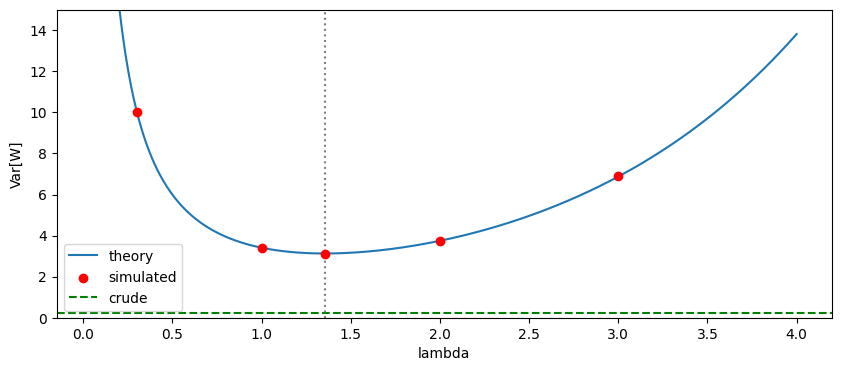

In [9]:
lams = np.linspace(0.05, 4, 800)
var_theory = (np.exp(2+lams)-1)/(lams*(2+lams)) - THETA**2
lam_opt = lams[np.argmin(var_theory)]
print(f"optimal lambda ~ {lam_opt:.3f}  Var[W]={var_theory.min():.3f}  (crude {VAR_CRUDE:.3f})")

def is_W(lam, n, rng):
    Y = rng.exponential(1/lam, n); inside = (Y >= 0) & (Y <= 1)
    return np.where(inside, np.exp(Y)/(lam*np.exp(-lam*Y)), 0.0)

grid = [0.3, lam_opt, 1.0, 2.0, 3.0]
sim = [is_W(l, 200_000, rng).var(ddof=1) for l in grid]
plt.plot(lams, var_theory, label="theory")
plt.scatter(grid, sim, color="red", zorder=5, label="simulated")
plt.axhline(VAR_CRUDE, color="green", ls="--", label="crude")
plt.axvline(lam_opt, color="gray", ls=":"); plt.ylim(0, 15)
plt.xlabel("lambda"); plt.ylabel("Var[W]"); plt.legend(); plt.show()

Optimal $\lambda\approx1.35$, but even then $\mathbb V[W]\approx3.1 \gg 0.242$: the decreasing
$e^{-\lambda x}$ is a poor match for the increasing $e^x$, so this proposal family worsens variance.

## Part 9 — Optimal proposal (discussion + check)

The variance-minimising IS proposal is $g^\*(x)\propto h(x)f(x)$, giving constant weight and zero
variance. For the Pareto mean this is the **first-moment distribution** $G_1\propto x f(x)$ (meaningful but
circular — it needs $\mathbb E[X]$). Generalises to any $\theta=\int hf$: optimal $g^\*=hf/\theta$. So in
Part 8 one should use $g\propto e^x$, not $e^{-\lambda x}$. Check with $g^\*(x)=e^x/(e-1)$ on $[0,1]$:

In [10]:
U = rng.random(100_000)
Y = np.log(1 + U*(np.e - 1))             # inverse transform for g*(x)=e^x/(e-1)
W = np.exp(Y) / (np.exp(Y)/(np.e - 1))   # = e-1 exactly
print(f"optimal g*: estimate {W.mean():.6f} (true {THETA:.6f}), Var[W]={W.var():.2e} (~0)")

optimal g*: estimate 1.718282 (true 1.718282), Var[W]=2.06e-31 (~0)
